In [151]:
import typing as t

import numpy as np
import matplotlib.pyplot as plt

INITIAL_MIDPRICE: t.Final[int] = 50
VARIANCE_ANNUAL: t.Final[float] = 2.51

DAYS_PER_YEAR: t.Final[int] = 252
DAYS_PER_WEEK: t.Final[int] = 5
STEPS_PER_DAY: t.Final[int] = 4
STEPS_PER_YEAR: t.Final[int] = DAYS_PER_YEAR * STEPS_PER_DAY

STEPS_PER_THREE_WEEKS: t.Final[int] = STEPS_PER_DAY * DAYS_PER_WEEK * 3
VARIANCE_PER_STEP: t.Final[float] = VARIANCE_ANNUAL * np.sqrt(1 / STEPS_PER_YEAR)

In [152]:
def generate_price_paths(
    num_paths: int = 100, steps: int = STEPS_PER_THREE_WEEKS
) -> list[np.array]:
    paths: list[np.array] = []

    for _ in range(num_paths):
        path: np.array[np.float64] = np.zeros(steps + 1)
        path[0] = INITIAL_MIDPRICE

        for t in range(steps):
            Z: float = np.random.normal()
            log_return: float = -0.5 * VARIANCE_PER_STEP**2 + Z * VARIANCE_PER_STEP

            path[t + 1] = path[t] * np.exp(log_return)

        paths.append(path)

    return paths


def generate_price_paths_chart(
    price_paths: list[np.array],
) -> plt.Figure:
    fig, ax = plt.subplots()

    for path in price_paths:
        ax.plot(path, alpha=0.6)

    ax.set_title("Geometric Brownian Motion Price Paths (σ = 251% annualized)")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Price")
    ax.grid(True)

    plt.close(fig)

    return fig


def generate_last_price_chat(last_prices: np.array) -> plt.Figure:
    fig, ax = plt.subplots()

    ax.scatter(x=list(range(len(last_prices))), y=last_prices)
    plt.axhline(
        y=np.mean(last_prices),
        color="r",
        linestyle="--",
        label=f"Mean last price: {np.mean(last_prices):.2f}",
    )
    ax.set_title(f"Last prices across {len(last_prices)} simulations")
    ax.set_ylabel("Price")
    ax.set_xlabel("Simulation number")
    ax.grid(True)
    ax.legend()

    plt.close(fig)

    return fig

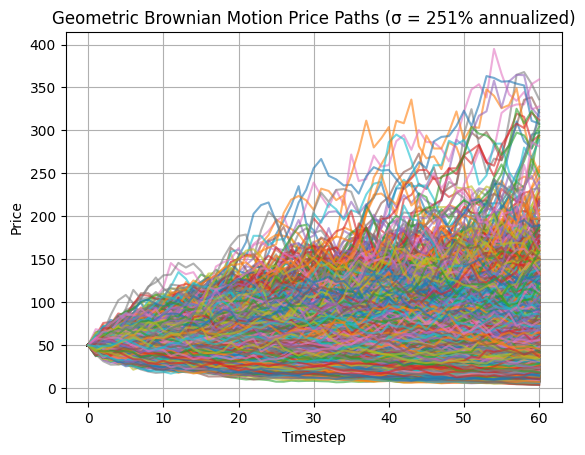

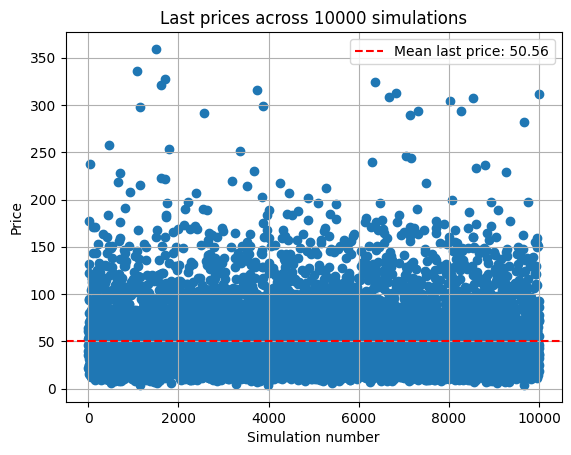

In [153]:
price_paths: list[np.array] = generate_price_paths(num_paths=10000)
last_prices: np.array = np.array([pp[-1] for pp in price_paths])
two_week_prices: np.array = np.array([pp[40] for pp in price_paths])
price_paths_vis = generate_price_paths_chart(price_paths)
last_price_vis = generate_last_price_chat(last_prices)

display(price_paths_vis)
display(last_price_vis)

In [154]:
## AC_50_C: Vanilla call option with strike price 50 and TTE 3 weeks
## AC_50_P: Vanilla put option with strike price 50 and TTE 3 weeks

call_bid, call_ask = 12, 12.05
put_bid, put_ask = 12, 12.05

strike_price = 50

call_payoffs = np.maximum(last_prices - strike_price, 0)
put_payoffs = np.maximum(strike_price - last_prices, 0)

call_payoffs_std = np.std(call_payoffs)
put_payoffs_std = np.std(put_payoffs)

call_fair_value = np.mean(call_payoffs)
put_fair_value = np.mean(put_payoffs)

print(f"Call payoffs std: {call_payoffs_std}")
print(f"Put payoffs std: {put_payoffs_std}\n")

print(f"Call fair value: {call_fair_value}")
print(f"Put fair value: {put_fair_value}\n")

call_edge_buy = call_fair_value - call_ask
call_edge_sell = call_bid - call_fair_value

put_edge_buy = put_fair_value - put_ask
put_edge_sell = put_bid - put_fair_value

print(f"Call edge buy: {call_edge_buy}")
print(f"Call edge sell: {call_edge_sell}\n")

print(f"Put edge buy: {put_edge_buy}")
print(f"Put edge sell: {put_edge_sell}")

Call payoffs std: 26.423968932395045
Put payoffs std: 12.49519863321237

Call fair value: 12.23327095646114
Put fair value: 11.676608699831775

Call edge buy: 0.1832709564611399
Call edge sell: -0.2332709564611406

Put edge buy: -0.3733913001682261
Put edge sell: 0.32339130016822537


In [155]:
## AC_50_C_2: Vanilla call option with strike price 50 and TTE 2 weeks
## AC_50_P_2: Vanilla put option with strike price 50 and TTE 2 weeks

call_2_bid, call_2_ask = 9.7, 9.75
put_2_bid, put_2_ask = 9.7, 9.75

strike_price_2 = 50

call_2_payoffs = np.maximum(two_week_prices - strike_price_2, 0)
put_2_payoffs = np.maximum(strike_price_2 - two_week_prices, 0)

call_2_payoffs_std = np.std(call_2_payoffs)
put_2_payoffs_std = np.std(put_2_payoffs)

call_2_fair_value = np.mean(call_2_payoffs)
put_2_fair_value = np.mean(put_2_payoffs)

print(f"Call 2 payoffs std: {call_2_payoffs_std}")
print(f"Put 2 payoffs std: {put_2_payoffs_std}\n")

print(f"Call 2 fair value: {call_2_fair_value}")
print(f"Put 2 fair value: {put_2_fair_value}\n")

call_2_edge_buy = call_2_fair_value - call_2_ask
call_2_edge_sell = call_2_bid - call_2_fair_value

put_2_edge_buy = put_2_fair_value - put_2_ask
put_2_edge_sell = put_2_bid - put_2_fair_value

print(f"Call 2 edge buy: {call_2_edge_buy}")
print(f"Call 2 edge sell: {call_2_edge_sell}\n")

print(f"Put 2 edge buy: {put_2_edge_buy}")
print(f"Put 2 edge sell: {put_2_edge_sell}")

Call 2 payoffs std: 19.942210567524974
Put 2 payoffs std: 10.861684320175168

Call 2 fair value: 10.079971562196613
Put 2 fair value: 9.655724948859238

Call 2 edge buy: 0.3299715621966133
Call 2 edge sell: -0.379971562196614

Put 2 edge buy: -0.0942750511407624
Put 2 edge sell: 0.04427505114076169
